In [23]:
# Pandas pour manipuler les tableaux de données
import pandas as pd
pd.set_option('display.max_columns', 500)

# Numpy pour les listes de données numériques et les fonctions classiques mathématiques
import numpy as np

# scipy (librairie scientifique) pour les fonctions statistiques et autres utilisaires
import scipy

# scikit learn pour les outils de machine learning
import sklearn
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

# librairies pour la visualisation de données
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# et quelques options visuelles
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set(style="whitegrid", color_codes=True)
sns.set(rc={'figure.figsize':(15,8)})

In [24]:
# cette fonction évalue la corrélation entre variables qualitatives en 
# - élaboration du tableau de contingence des valeurs
# - calcul du chi2 de cet tableau 
# - calcul du coefficient de cramer qui est une normalisation du coefficient chi2
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = scipy.stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

In [25]:
# élaboration de deux listes de variables aléatoires
x = np.random.randint(0,20, size=1000)
y = np.random.randint(0,20, size=1000)

In [26]:
# test pour deux listes décorrélées
cramers_v(x,y)

np.float64(0.0)

In [27]:
# test pour deux listes totalement corrélées
cramers_v(x,x)

np.float64(1.0)

In [28]:
def eta_squared(x,y):
    moyenne_y = y.mean()
    classes = []
    for classe in x.unique():
        yi_classe = y[x==classe]
        classes.append({'ni': len(yi_classe),
                        'moyenne_classe': yi_classe.mean()})
    SCT = sum([(yj-moyenne_y)**2 for yj in y])
    SCE = sum([c['ni']*(c['moyenne_classe']-moyenne_y)**2 for c in classes])
    return SCE/SCT

In [29]:
# les données ont été téléchargées sur kaggle et enregistrées en local 
# dans un répertoire similaire que celui en ligne sur kaggle, ainsi le script
# pourra tourner aussi bien en ligne qu'en local
train = pd.read_csv('../data/train.csv')
test =  pd.read_csv('../data/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
# affichage des 5 premières lignes du jeu de test
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [31]:
test['Survived']=np.nan
data=pd.concat([train,test],keys=['train','test'], join='inner')
data.index=data.index.droplevel(level=1)

In [32]:
len(data)

1309

In [33]:
len(data.loc['test'])

418

In [34]:
# affichage de la liste et format des différentes variables
data.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, train to test
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 165.2+ KB


In [35]:
# est-ce qu'il y a des doublons dans les identifiants
data.PassengerId.duplicated().sum()

np.int64(0)

In [36]:
# describe permet d'avoir quelques éléments statistiques sur les données
data.PassengerId.describe()

count    1309.000000
mean      655.000000
std       378.020061
min         1.000000
25%       328.000000
50%       655.000000
75%       982.000000
max      1309.000000
Name: PassengerId, dtype: float64

In [37]:
# liste des valeurs prises par Survived, on utilise value_counts() qui permet de lister les valeurs prise 
# pas une variable donnée ainsi que l'occurence de chaque valeur
data.Survived.value_counts()

Survived
0.0    549
1.0    342
Name: count, dtype: int64

In [38]:
# liste des valeurs prises par Pclass
data.Pclass.value_counts()

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [ ]:
correlation = {}
correlation['Pclass']=cramers_v(data.loc['train','Pclass'],data.loc['train','Survived'])
print(correlation['Pclass'])

In [ ]:
pd.crosstab(data["Survived"],data["Pclass"])

In [45]:
data.Name

train                              Braund, Mr. Owen Harris
train    Cumings, Mrs. John Bradley (Florence Briggs Th...
train                               Heikkinen, Miss. Laina
train         Futrelle, Mrs. Jacques Heath (Lily May Peel)
train                             Allen, Mr. William Henry
                               ...                        
test                                    Spector, Mr. Woolf
test                          Oliva y Ocana, Dona. Fermina
test                          Saether, Mr. Simon Sivertsen
test                                   Ware, Mr. Frederick
test                              Peter, Master. Michael J
Name: Name, Length: 1309, dtype: str

In [46]:
data['Title'] = data['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

In [47]:
data.Title.value_counts()

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

In [49]:
data['Title']=data['Title'].replace(['Major','Don','Jonkheer','Capt','Sir'], 'Mr')
data['Title']=data['Title'].replace(['Mlle'], 'Miss')
data['Title']=data['Title'].replace(['Lady','the Countess','Mme','Ms','Dona'], 'Mrs')
data.Title.value_counts()

Title
Mr        763
Miss      262
Mrs       203
Master     61
Rev         8
Dr          8
Col         4
Name: count, dtype: int64

In [50]:
data['Last Name'] = data['Name'].str.split(", ", expand=True)[0]

In [51]:
data['Last Name'].describe()

count          1309
unique          875
top       Andersson
freq             11
Name: Last Name, dtype: object

In [52]:
data.loc['train'].groupby('Last Name').agg({'Survived': 'var'}).mean()

Survived    0.16863
dtype: float64

In [53]:
data['randNumCol'] = np.random.choice(2,len(data))

In [54]:
data.loc['train'].groupby('Last Name').agg({'randNumCol': 'var'}).mean()

randNumCol    0.275683
dtype: float64

In [55]:
data=data.drop('randNumCol',axis=1)

In [56]:
from sklearn import preprocessing
MyEncoder=preprocessing.LabelEncoder()
MyEncoder.fit(data['Last Name'].sort_values())
data['LastNameNum'] = MyEncoder.transform(data['Last Name'])
data.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Last Name,LastNameNum
train,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Mr,Braund,100


In [58]:
data['First Name'] = data['Name'].str.split("\. ", expand=True)[1].str.split(" ", expand=True)[0]

In [59]:
data['First Name'].head()

train       Owen
train       John
train      Laina
train    Jacques
train    William
Name: First Name, dtype: str

In [60]:
gender = {'male': 1,'female': 0}
data.Sex = [gender[item] for item in data.Sex]

<Axes: xlabel='Age', ylabel='Density'>

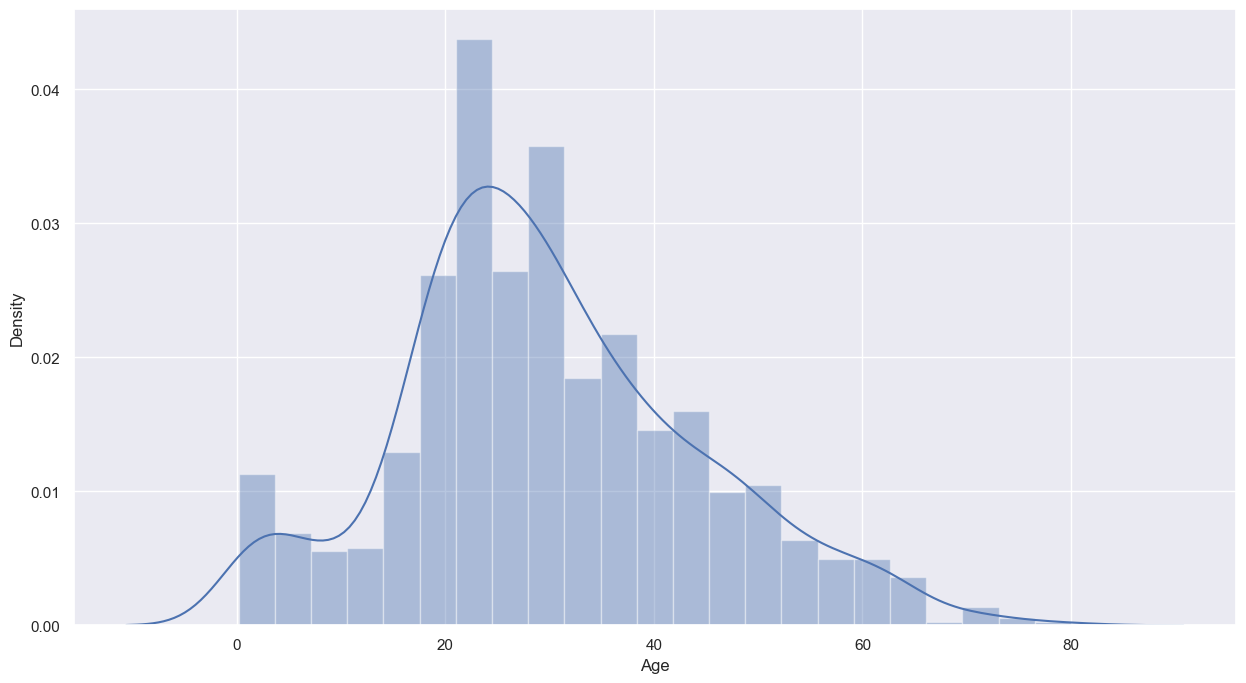

In [61]:
sns.distplot(data.Age.dropna())

In [62]:
data.Age.describe()

count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: Age, dtype: float64

In [63]:
scipy.stats.shapiro(data.Age.dropna())

ShapiroResult(statistic=np.float64(0.9795473058205418), pvalue=np.float64(5.7471412971652014e-11))

In [65]:
dataTemp = data.loc['train'].dropna(subset=['Age'])

In [66]:
data['TicketSibling'] = data.groupby('Ticket')['Ticket'].transform('count')

In [67]:
data.loc[(data.Age.isna())&(data['TicketSibling']==1),'Age']=30

In [68]:
data.loc[(data.Age.notna())&(data.Title=="Mrs"),'Age'].mean()

np.float64(36.65384615384615)

In [69]:
data.loc[(data.Age.isna())&(data.Title=="Mrs"),'Age']=37